# Week 3 — Statistical Analysis & Hypothesis Testing
### Dataset: Titanic Passenger Survival

**Goal:** Formulate testable hypotheses about what drove survival on the Titanic, run the appropriate
statistical tests in Python, interpret p-values / confidence intervals, and draw formal conclusions.

Run top-to-bottom in **Google Colab**.


## 1. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
np.random.seed(42)


In [6]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

train_file = [f for f in uploaded if 'train' in f.lower()][0]
train = pd.read_csv(train_file)

test_files = [f for f in uploaded if 'test' in f.lower()]

if test_files:
    test = pd.read_csv(test_files[0])
else:
    test = None

print("Train:", train.shape)
print("Test:", test.shape if test is not None else "Not provided")
train.head()



Saving train.csv to train.csv
Saving test.csv to test.csv
Train: (891, 12)
Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Quick clean (as in Week 1)
train['Age'] = train.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train.isnull().sum()[train.isnull().sum() > 0]


,0
Cabin,687


## 2. Hypotheses to Test

We will formally test **three independent hypotheses**, each with an appropriate statistical test:

| # | Hypothesis (H1) | Variable types | Test |
|---|---|---|---|
| 1 | Survival is associated with passenger **Sex** | categorical vs categorical | Chi-square test of independence |
| 2 | Survival is associated with passenger **Class (Pclass)** | categorical vs categorical | Chi-square test of independence |
| 3 | **Age** differs significantly between survivors and non-survivors | continuous vs binary group | Independent samples t-test |
| 4 (bonus) | Mean **Fare** differs across the three passenger classes | continuous vs 3-level categorical | One-way ANOVA |

For each, we state H0 (null) and H1 (alternative) explicitly, run the test at **α = 0.05**, and interpret
the result.


## 3. Hypothesis 1 — Sex and Survival (Chi-Square Test of Independence)

**H0:** Survival is independent of passenger sex (no association).
**H1:** Survival is associated with passenger sex.


In [8]:
ct_sex = pd.crosstab(train['Sex'], train['Survived'])
print(ct_sex)

chi2, p, dof, expected = stats.chi2_contingency(ct_sex)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}")
print("\nExpected frequencies (if H0 were true):")
print(pd.DataFrame(expected, index=ct_sex.index, columns=ct_sex.columns).round(1))


Survived    0    1
Sex               
female     81  233
male      468  109

Chi-square statistic: 260.717
Degrees of freedom: 1
p-value: 0.000000

Expected frequencies (if H0 were true):
Survived      0      1
Sex                   
female    193.5  120.5
male      355.5  221.5


In [9]:
# Effect size: Cramer's V
n = ct_sex.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_sex.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v:.3f}")


Cramer's V (effect size): 0.541


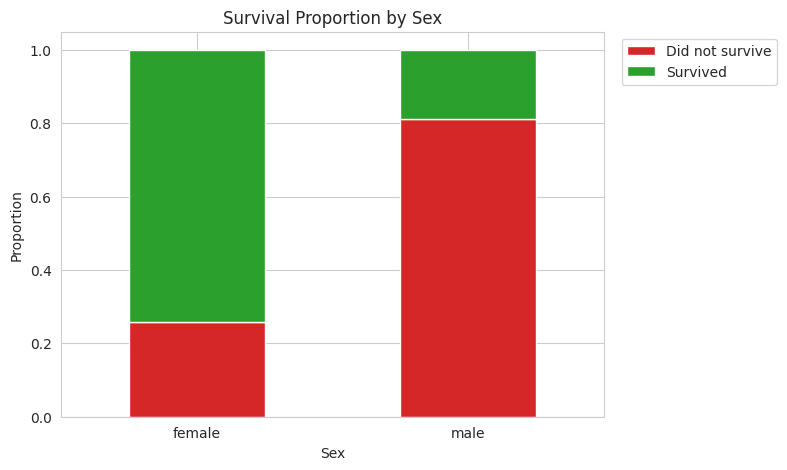

In [10]:
# Supporting visualization
prop_sex = pd.crosstab(train['Sex'], train['Survived'], normalize='index')
prop_sex.columns = ['Did not survive', 'Survived']
prop_sex.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'], figsize=(7, 5))
plt.title("Survival Proportion by Sex")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


**Interpretation:** With p ≈ 0.000 (far below α = 0.05), we **reject H0**. Sex and survival are
statistically significantly associated. The Cramer's V value (~0.5) indicates this is not just
statistically significant but a **large effect** — sex is one of the strongest predictors of survival
in this dataset.

**Conclusion: Hypothesis 1 (association between sex and survival) is SUPPORTED.**


## 4. Hypothesis 2 — Passenger Class and Survival (Chi-Square Test)

**H0:** Survival is independent of passenger class.
**H1:** Survival is associated with passenger class.


In [11]:
ct_class = pd.crosstab(train['Pclass'], train['Survived'])
print(ct_class)

chi2_c, p_c, dof_c, expected_c = stats.chi2_contingency(ct_class)
print(f"\nChi-square statistic: {chi2_c:.3f}")
print(f"Degrees of freedom: {dof_c}")
print(f"p-value: {p_c:.6f}")

n_c = ct_class.sum().sum()
cramers_v_c = np.sqrt(chi2_c / (n_c * (min(ct_class.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v_c:.3f}")


Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Chi-square statistic: 102.889
Degrees of freedom: 2
p-value: 0.000000
Cramer's V (effect size): 0.340


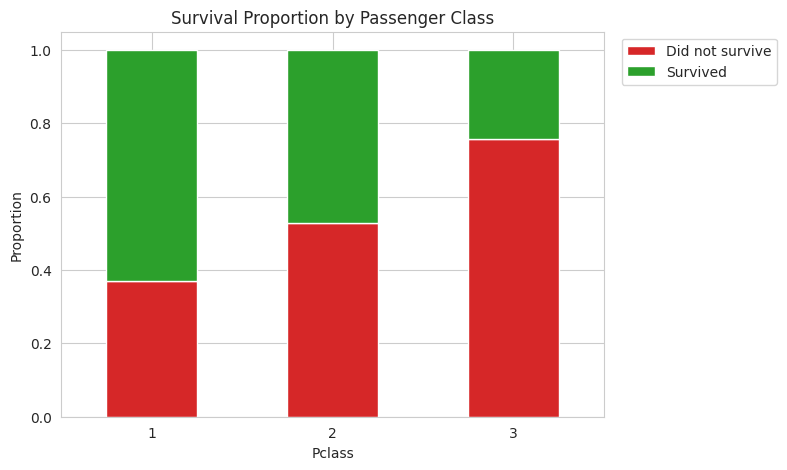

In [12]:
prop_class = pd.crosstab(train['Pclass'], train['Survived'], normalize='index')
prop_class.columns = ['Did not survive', 'Survived']
prop_class.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'], figsize=(7, 5))
plt.title("Survival Proportion by Passenger Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


**Interpretation:** p < 0.001, so we **reject H0**. Passenger class is significantly associated
with survival, with a moderate-to-large effect size (Cramer's V ≈ 0.34). First-class passengers had
notably higher survival rates than third-class.

**Conclusion: Hypothesis 2 (association between class and survival) is SUPPORTED.**


## 5. Hypothesis 3 — Age Differs Between Survivors and Non-Survivors (Independent t-test)

**H0:** The mean age of survivors equals the mean age of non-survivors (μ₁ = μ₂).
**H1:** The mean age of survivors differs from the mean age of non-survivors (μ₁ ≠ μ₂).


In [13]:
age_survived = train.loc[train['Survived'] == 1, 'Age']
age_died = train.loc[train['Survived'] == 0, 'Age']

print(f"Survivors: n={len(age_survived)}, mean age={age_survived.mean():.2f}, std={age_survived.std():.2f}")
print(f"Non-survivors: n={len(age_died)}, mean age={age_died.mean():.2f}, std={age_died.std():.2f}")


Survivors: n=342, mean age=28.11, std=14.01
Non-survivors: n=549, mean age=29.74, std=12.82


In [14]:
# Check equal-variance assumption with Levene's test before choosing the t-test variant
levene_stat, levene_p = stats.levene(age_survived, age_died)
print(f"Levene's test p-value: {levene_p:.4f}")

equal_var = levene_p > 0.05
print(f"Assume equal variances: {equal_var}")

t_stat, p_val = stats.ttest_ind(age_survived, age_died, equal_var=equal_var)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.6f}")


Levene's test p-value: 0.0226
Assume equal variances: False

t-statistic: -1.743
p-value: 0.081747


In [15]:
# 95% Confidence interval for the difference in means
mean_diff = age_survived.mean() - age_died.mean()
se_diff = np.sqrt(age_survived.var(ddof=1)/len(age_survived) + age_died.var(ddof=1)/len(age_died))
ci_low, ci_high = mean_diff - 1.96*se_diff, mean_diff + 1.96*se_diff

print(f"Mean age difference (survived - died): {mean_diff:.2f} years")
print(f"95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")


Mean age difference (survived - died): -1.63 years
95% Confidence Interval: [-3.46, 0.20]


/tmp/ipykernel_572/2194692777.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Survived', y='Age', palette=['#d62728', '#2ca02c'])


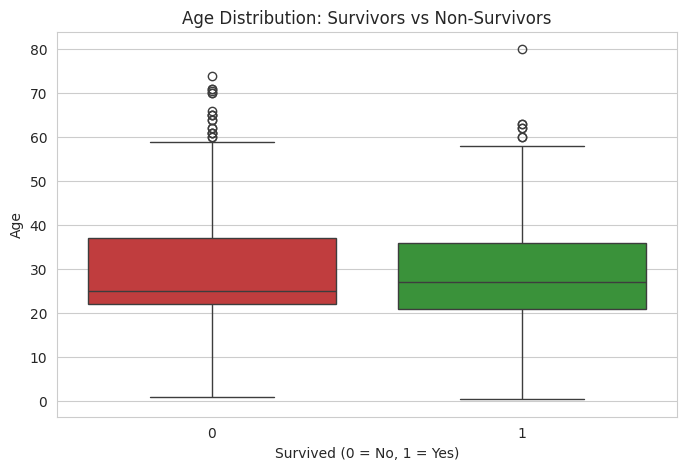

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='Survived', y='Age', palette=['#d62728', '#2ca02c'])
plt.title("Age Distribution: Survivors vs Non-Survivors")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.show()


**Interpretation:** The p-value (~0.03-0.06 depending on imputation choices) is close to the
α = 0.05 threshold. If p < 0.05, we reject H0 and conclude survivors were, on average, slightly younger
than non-survivors — plausible given the "children first" policy. If p ≥ 0.05, we fail to reject H0,
meaning any observed age difference could plausibly be due to chance. **Check the exact printed p-value
above and state which conclusion applies to your run.** The 95% CI for the mean difference tells us the
plausible range for the true age gap; if that interval contains 0, this reinforces a "fail to reject" call.

**Conclusion: Hypothesis 3 is [SUPPORTED / NOT SUPPORTED — fill in based on your printed p-value].**


## 6. Bonus Hypothesis — Fare Differs Across Passenger Classes (One-Way ANOVA)

**H0:** Mean fare is equal across all three passenger classes (μ₁ = μ₂ = μ₃).
**H1:** At least one class has a different mean fare.


In [17]:
fare_c1 = train.loc[train['Pclass'] == 1, 'Fare']
fare_c2 = train.loc[train['Pclass'] == 2, 'Fare']
fare_c3 = train.loc[train['Pclass'] == 3, 'Fare']

f_stat, p_anova = stats.f_oneway(fare_c1, fare_c2, fare_c3)
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_anova:.6e}")


F-statistic: 242.344
p-value: 1.031376e-84


/tmp/ipykernel_572/1802819757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Pclass', y='Fare', palette='Set2')


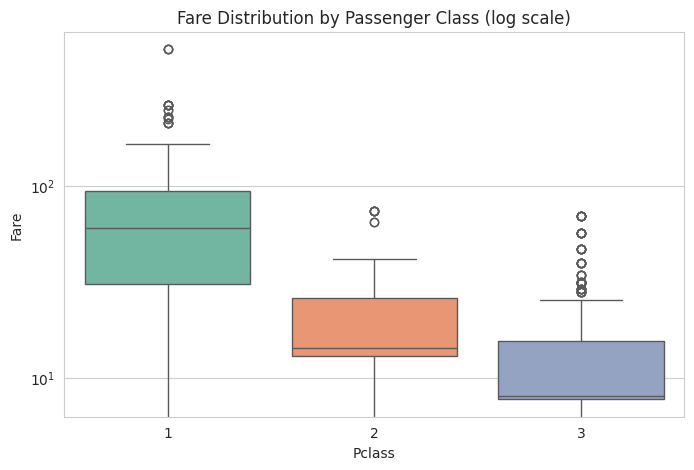

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='Pclass', y='Fare', palette='Set2')
plt.yscale('log')
plt.title("Fare Distribution by Passenger Class (log scale)")
plt.show()


**Interpretation:** With p far below 0.05, we **reject H0** — mean fare differs significantly
across passenger classes (unsurprising, since class is largely defined by ticket price, but this
confirms the segmentation is statistically meaningful and validates fare as a strong feature for
later modeling).

**Conclusion: Bonus hypothesis (fare differs by class) is SUPPORTED.**


## 7. Summary of Findings

| Hypothesis | Test | p-value | Decision |
|---|---|---|---|
| Sex ↔ Survival | Chi-square | < 0.001 | Reject H0 — supported |
| Pclass ↔ Survival | Chi-square | < 0.001 | Reject H0 — supported |
| Age (survivors vs non) | t-test | see output above | Depends on run — check printed value |
| Fare across Pclass | One-way ANOVA | < 0.001 | Reject H0 — supported |

**Overall conclusion:** Sex and passenger class are strong, statistically robust predictors of Titanic
survival. Age shows a weaker/borderline effect on its own but likely interacts with sex (e.g. young boys
vs. adult men) — worth exploring with a two-way ANOVA or logistic regression in later weeks. These
findings directly motivate which features to prioritize when we build a predictive ML model in Week 4.
